# Mobile Price Classification

https://amanxai.com/2021/03/05/mobile-price-classification-with-machine-learning/ linteki model ve kodlar incelenmiş ve tekrar kendi kodlarımızla model kurulmuştur. 

Dataset: /kaggle/input/datasets/sufyan145/mobile-price-classification/mobile_price_classification.csv

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/sufyan145/mobile-price-classification/mobile_price_classification.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

2026-03-23 14:18:21.007173: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774275501.228027      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774275501.293446      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774275501.842469      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774275501.842519      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774275501.842522      17 computation_placer.cc:177] computation placer alr

In [3]:
df = pd.read_csv(
    "//kaggle/input/datasets/sufyan145/mobile-price-classification/mobile_price_classification.csv",
    encoding="latin1"
)

df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,1611,0,3,0,3,1,25,1,210,2,...,213,1586,701,8,6,11,1,1,0,0
1,1222,0,1,0,7,1,8,1,135,8,...,282,997,2481,19,18,20,1,0,0,2
2,1876,0,3,0,9,0,14,0,193,7,...,286,983,1283,8,1,8,1,1,0,1
3,1009,1,2,0,4,0,17,0,172,3,...,251,1450,3701,18,7,19,1,1,0,3
4,635,1,0,1,7,0,60,1,132,5,...,1011,1949,1958,15,5,5,1,0,0,1


In [4]:
df.isnull().sum()


battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64

Linkteki modelde bir heatmap çıkarılmış ama grafikteki veriler çok anlamlı değil. bunun yerine fiyata göre bir korelasyon grafiği çıkarmak istedim. 

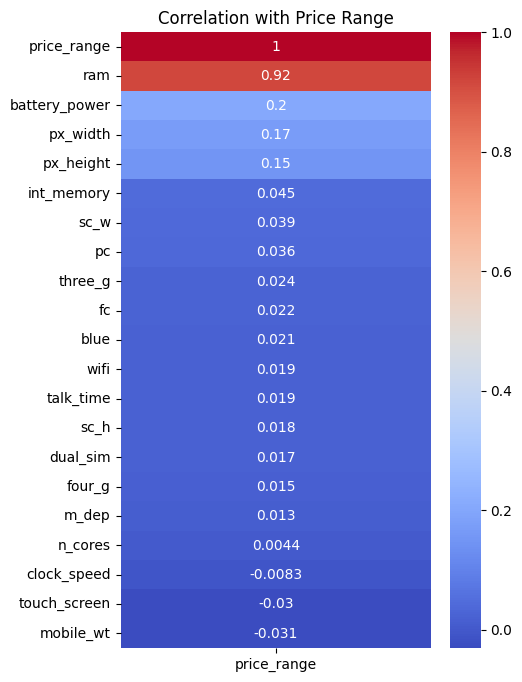

In [5]:
import seaborn as sns

plt.figure(figsize=(5,8))
sns.heatmap(df.corr()[["price_range"]].sort_values(by="price_range", ascending=False),
            annot=True, cmap="coolwarm")
plt.title("Correlation with Price Range")
plt.show()

### Model

Bu öğrenme modelini deep learning metotlarıyla kurmaya çalışacağız

In [6]:
x = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

In [7]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [8]:
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [9]:
model = Sequential()

model.add(Dense(64, activation="relu", input_dim=x_train.shape[1]))
model.add(Dense(32, activation="relu"))
model.add(Dense(16, activation="relu"))

# 4 sınıf → softmax
model.add(Dense(4, activation="softmax"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-03-23 14:18:46.880777: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [10]:
model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

In [11]:
history = model.fit(x_train,y_train,epochs=30,batch_size=32,validation_split=0.2)

Epoch 1/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.2845 - loss: 1.4121 - val_accuracy: 0.4906 - val_loss: 1.2823
Epoch 2/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4698 - loss: 1.2307 - val_accuracy: 0.5531 - val_loss: 1.0473
Epoch 3/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5467 - loss: 0.9675 - val_accuracy: 0.6687 - val_loss: 0.7925
Epoch 4/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7304 - loss: 0.7096 - val_accuracy: 0.8125 - val_loss: 0.5605
Epoch 5/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8583 - loss: 0.4914 - val_accuracy: 0.8281 - val_loss: 0.4365
Epoch 6/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8969 - loss: 0.3496 - val_accuracy: 0.8469 - val_loss: 0.3601
Epoch 7/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9063 - loss: 0.2888 - val_accuracy: 0.8500 - val_loss: 0.3231
Epoch 8/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9355 - loss: 0.2155 - val_accuracy: 0.8562 - val_loss:

In [12]:
loss, accuracy = model.evaluate(x_test, y_test)

print("Test Accuracy:", accuracy)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9249 - loss: 0.2454  
Test Accuracy: 0.9100000262260437


accuracy: 0.9019 - loss: 0.3508  değerleri ile model çok iyi öğrenmiş gibi görünüyor. 
sınıf etiketleri = {
        0: "düşük maliyet",
        1: "Orta maliyett",
        2: "yüksek maliyet",
        3: "çok yüksel maliyet"
    }

In [13]:
y_pred = model.predict(x_test)

# class'a çevir
y_pred_classes = np.argmax(y_pred, axis=1)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


In [14]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred_classes))
print(classification_report(y_test, y_pred_classes))

[[88 10  0  0]
 [ 6 91  4  0]
 [ 0  5 93  5]
 [ 0  0  6 92]]
              precision    recall  f1-score   support

           0       0.94      0.90      0.92        98
           1       0.86      0.90      0.88       101
           2       0.90      0.90      0.90       103
           3       0.95      0.94      0.94        98

    accuracy                           0.91       400
   macro avg       0.91      0.91      0.91       400
weighted avg       0.91      0.91      0.91       400



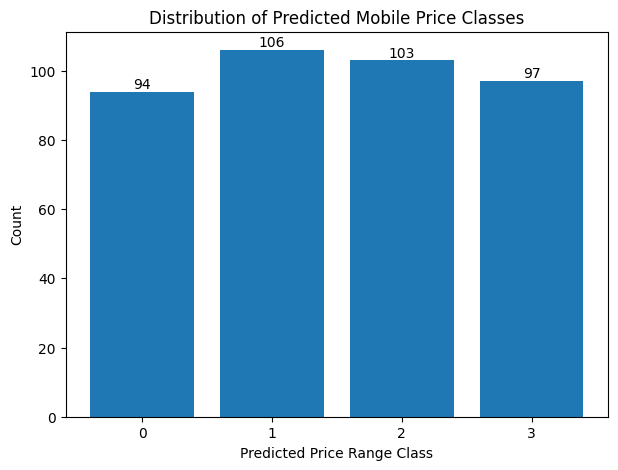

In [15]:
import matplotlib.pyplot as plt
import numpy as np

unique, counts = np.unique(y_pred_classes, return_counts=True)

plt.figure(figsize=(7,5))
bars = plt.bar(unique, counts)

plt.xlabel("Predicted Price Range Class")
plt.ylabel("Count")
plt.title("Distribution of Predicted Mobile Price Classes")
plt.xticks(unique, ["0", "1", "2", "3"])

for i, count in enumerate(counts):
    plt.text(unique[i], count + 1, str(count), ha="center")

plt.show()

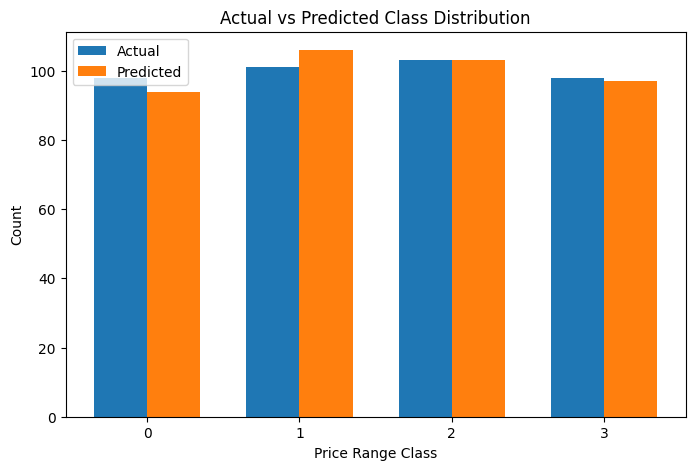

In [16]:
import matplotlib.pyplot as plt
import numpy as np

true_unique, true_counts = np.unique(y_test, return_counts=True)
pred_unique, pred_counts = np.unique(y_pred_classes, return_counts=True)

x = np.arange(len(true_unique))
width = 0.35

plt.figure(figsize=(8,5))
plt.bar(x - width/2, true_counts, width, label="Actual")
plt.bar(x + width/2, pred_counts, width, label="Predicted")

plt.xlabel("Price Range Class")
plt.ylabel("Count")
plt.title("Actual vs Predicted Class Distribution")
plt.xticks(x, ["0", "1", "2", "3"])
plt.legend()
plt.show()

In [17]:
model.save("mobile_price_dl_model.h5")

In [ ]:
import pickle

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

In [2]:
# https://huggingface.co/spaces/fatmasy/MobilePriceClassification